# **Implementación de Modelos Benchmark para Forecasting Multi-horizonte de `temp_c`**



## **1. Diseño Experimental**

### **1.1 Variables de entrada y objetivo**

In [8]:
import sys
import os
from pathlib import Path

# Resolución robusta de la raíz del repo
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "config").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import pandas as pd

variables = pd.DataFrame([
    # Target
    {"nombre": "temp_c", "descripcion": "Temperatura del aire (target)",
     "unidad": "°C", "fuente": "INMET", "incluida": "TARGET",
     "justificacion": "Variable objetivo del proyecto."},
    # Exógenas dinámicas (selección del EDA, sec. 6)
    {"nombre": "humidity_pct", "descripcion": "Humedad relativa",
     "unidad": "%", "fuente": "INMET", "incluida": "sí (input)",
     "justificacion": "|corr|≈0.6 con temp_c; MI alta (EDA §6)."},
    {"nombre": "pressure_mb", "descripcion": "Presión atmosférica al nivel de estación",
     "unidad": "mb", "fuente": "INMET", "incluida": "sí (input)",
     "justificacion": "Correlación moderada y CCF informativa con lead 1–3 h."},
    {"nombre": "radiation_kj_m2", "descripcion": "Radiación global",
     "unidad": "kJ/m²", "fuente": "INMET", "incluida": "sí (input, con cuidado)",
     "justificacion": "CCF muestra que adelanta a temp_c 2–4 h. ~21 % NaN nocturnos legítimos — el modelo descarta ventanas con NaN remanente, no se imputa con 0."},
    {"nombre": "wind_speed_ms", "descripcion": "Velocidad del viento",
     "unidad": "m/s", "fuente": "INMET", "incluida": "sí (input)",
     "justificacion": "MI moderada con temp_c; capta enfriamiento por advección."},
    {"nombre": "dew_point_c", "descripcion": "Punto de rocío",
     "unidad": "°C", "fuente": "INMET", "incluida": "sí (input)",
     "justificacion": "Alta correlación con humidity (multicolinealidad aceptada en redes profundas)."},
    {"nombre": "precip_mm", "descripcion": "Precipitación horaria",
     "unidad": "mm", "fuente": "INMET", "incluida": "no",
     "justificacion": "Correlación ≈ 0 con temp_c; MI baja (EDA §6) — descartada."},
    {"nombre": "wind_dir_deg", "descripcion": "Dirección del viento (cruda)",
     "unidad": "°", "fuente": "INMET", "incluida": "no (cruda)",
     "justificacion": "No lineal en grados; entra vía wind_dir_sin/cos en features.py."},
    # Cíclicas
    {"nombre": "hour_sin / hour_cos", "descripcion": "Codificación cíclica de la hora",
     "unidad": "—", "fuente": "derivada (process.py)", "incluida": "sí (known future)",
     "justificacion": "FFT del EDA confirma pico dominante a 24 h."},
    {"nombre": "doy_sin / doy_cos", "descripcion": "Codificación cíclica del día del año",
     "unidad": "—", "fuente": "derivada (process.py)", "incluida": "sí (known future)",
     "justificacion": "FFT del EDA confirma pico anual ~8766 h; STL ~50–80 % varianza estacional."},
    {"nombre": "month_sin / month_cos", "descripcion": "Codificación cíclica del mes",
     "unidad": "—", "fuente": "derivada (process.py)", "incluida": "sí (known future)",
     "justificacion": "Granularidad mensual complementaria; útil para desambiguar tendencia anual y anomalías estacionales."},
    # Estáticas (metadata por estación)
    {"nombre": "station_id", "descripcion": "ID entero por estación (40 niveles)",
     "unidad": "—", "fuente": "process.py + stations.yaml", "incluida": "sí (static categórica)",
     "justificacion": "Embedding por estación absorbe el nivel base climático local."},
    {"nombre": "region", "descripcion": "Macrorregión IBGE (5 niveles)",
     "unidad": "—", "fuente": "stations.yaml", "incluida": "sí (static categórica)",
     "justificacion": "Captura heterogeneidad regional dramática observada en EDA §7."},
    {"nombre": "biome", "descripcion": "Bioma (6 niveles)",
     "unidad": "—", "fuente": "stations.yaml", "incluida": "sí (static categórica)",
     "justificacion": "Cardinalidad baja, alta información (Caatinga ≠ Pampa)."},
    {"nombre": "koppen_class", "descripcion": "Clase Köppen-Geiger (9 niveles)",
     "unidad": "—", "fuente": "stations.yaml", "incluida": "sí (static categórica)",
     "justificacion": "Granularidad climática más fina que region/biome."},
    {"nombre": "latitude", "descripcion": "Latitud de la estación",
     "unidad": "°", "fuente": "metadata.json", "incluida": "sí (static real)",
     "justificacion": "Información geográfica continua; correlación lineal moderada con temp_c (Pearson)."},
    {"nombre": "longitude", "descripcion": "Longitud de la estación",
     "unidad": "°", "fuente": "metadata.json", "incluida": "sí (static real, normalizada)",
     "justificacion": "Información geográfica continua; entra como feature estática estandarizada."},
    {"nombre": "altitude", "descripcion": "Altitud de la estación",
     "unidad": "m", "fuente": "metadata.json", "incluida": "sí (static real)",
     "justificacion": "Modula directamente el régimen térmico (gradiente vertical)."},
])
variables

,nombre,descripcion,unidad,fuente,incluida,justificacion
0,temp_c,Temperatura del aire (target),°C,INMET,TARGET,Variable objetivo del proyecto.
1,humidity_pct,Humedad relativa,%,INMET,sí (input),|corr|≈0.6 con temp_c; MI alta (EDA §6).
2,pressure_mb,Presión atmosférica al nivel de estación,mb,INMET,sí (input),Correlación moderada y CCF informativa con lea...
3,radiation_kj_m2,Radiación global,kJ/m²,INMET,"sí (input, con cuidado)",CCF muestra que adelanta a temp_c 2–4 h. ~21 %...
4,wind_speed_ms,Velocidad del viento,m/s,INMET,sí (input),MI moderada con temp_c; capta enfriamiento por...
5,dew_point_c,Punto de rocío,°C,INMET,sí (input),Alta correlación con humidity (multicolinealid...
6,precip_mm,Precipitación horaria,mm,INMET,no,Correlación ≈ 0 con temp_c; MI baja (EDA §6) —...
7,wind_dir_deg,Dirección del viento (cruda),°,INMET,no (cruda),No lineal en grados; entra vía wind_dir_sin/co...
8,hour_sin / hour_cos,Codificación cíclica de la hora,—,derivada (process.py),sí (known future),FFT del EDA confirma pico dominante a 24 h.
9,doy_sin / doy_cos,Codificación cíclica del día del año,—,derivada (process.py),sí (known future),FFT del EDA confirma pico anual ~8766 h; STL ~...


**Target multi-horizonte.** El proyecto predice `temp_c` a tres horizontes
simultáneos: **+24 h, +72 h, +168 h**. Estrategia: el modelo emite un vector de
**168 pasos** y la evaluación se reporta por separado para cuts en {24, 72, 168}.


### **1.2 Partición del dataset**

| Split | Años | Origen del filtro | # estaciones | Filas/estación (aprox.) |
|---|---|---|---|---|
| **Train** | 2018, 2019, 2020, 2021, 2022, 2023 | `cfg.split.by_year.train_years` | 40 | ~52 584 |
| **Val** | 2024 | `cfg.split.by_year.val_years` | 39 (A301 sin 2024) | ~8 784 |
| **Test** | 2025 | `cfg.split.by_year.test_years` | 38 (A301 y A615 sin 2025) | ~8 760 |

**Garantía formal de no-leakage**:

```text
max(train.index) = 2023-12-31 23:00:00  <  2024-01-01 00:00:00 = min(val.index)
max(val.index)   = 2024-12-31 23:00:00  <  2025-01-01 00:00:00 = min(test.index)
```

Validado automáticamente por `tests/test_split_real_data.py::test_no_leakage_on_real_data`
sobre `data/processed/A001.parquet`.

>  **Bloque anti-leakage del entrenamiento**
>
> 1. **Scaler fit** sólo en `train` — `FeatureScaler.fit(..., source="train")`
>    en `src/data/scalers.py`, validado por `test_scaler_fit_train_only.py`.
> 2. **Ventaneo** no cruza fronteras de split — `make_windows` genera ventanas
>    completamente contenidas en cada split, validado por
>    `test_windowing_no_leakage.py`.
> 3. **Imputación causal** — `process.py` usa `ffill(limit=6)`; ventanas con
>    NaN remanente se descartan en `make_windows`, no se rellenan con la media
>    (que sería leakage de estadísticos globales).

### **1.3 Pipeline de preprocesamiento**

```text
data/processed/<wmo>.parquet                 (ya escrito por src.data.process)
        │
        ▼
[carga panel] load_parquet(...) por estación
        │
        ▼
[split temporal por años]   train (2018–2023)  |  val (2024)  |  test (2025)
        │                                                   │
        ▼                                                   ▼
[FeatureScaler.fit en train]  ────────────────────► [transform val/test]
        │
        ▼
[make_windows]   X (B, lookback=168, n_features),  y (B, horizon=168, n_targets)
        │
        ▼
[DataLoader]   batch=64, shuffle=True (train), False (val/test)
        │
        ▼
[runner.py]   instancia modelo y entrena con Trainer
```

La función `_resolve_feature_cols` del runner devuelve el conjunto de
features de entrada (todo numérico excepto los targets, más los targets
listados como exógenos si el modo es multitarget). El target sale del
config (`task.target = "temp_c"`).

In [ ]:


from src.utils import load_yaml
from src.data.windowing import make_windows
from src.data.scalers import FeatureScaler

cfg = load_yaml("config/config.yaml")
print("Target :", cfg["task"]["target"])
print("Exog   :", cfg["task"]["exog"])
print("Lookback:", cfg["task"]["lookback"], "h")
print("Horizon :", cfg["task"]["horizon"], "h  (cambiar a 168 para multi-horizonte)")
print("Freq   :", cfg["task"]["freq"])


if False:
    import pandas as pd
    df_train = pd.read_parquet("data/processed/A001.parquet")
    df_train = df_train[df_train.index.year.isin(cfg["split"]["by_year"]["train_years"])]
    feats = ["humidity_pct", "pressure_mb", "radiation_kj_m2", "wind_speed_ms", "dew_point_c"]
    tgts = [cfg["task"]["target"]]
    w = make_windows(df_train, feats, tgts, cfg["task"]["lookback"], cfg["task"]["horizon"])
    print("X shape:", w.X.shape, "y shape:", w.y.shape)
    fx = FeatureScaler(name=cfg["scaling"]["method"]).fit(w.X, source="train")
    Xtr = fx.transform(w.X)

Target : temp_c
Exog   : ['humidity_pct', 'pressure_mb', 'radiation_kj_m2', 'wind_speed_ms']
Lookback: 168 h
Horizon : 24 h  (cambiar a 168 para multi-horizonte)
Freq   : h


### **1.4 Configuración experimental base**

In [10]:
# Lectura de la config global y de los configs por modelo.
import yaml
from pathlib import Path

cfg_global = load_yaml("config/config.yaml")
configs_dir = Path("config/models")
model_configs = {p.stem: load_yaml(p) for p in sorted(configs_dir.glob("*.yaml"))}

print("Modelos con config:", sorted(model_configs.keys()))
print()
print("Hiperparámetros globales (cfg.training):")
for k, v in cfg_global["training"].items():
    print(f"  {k:25s} = {v}")
print()
print("Semillas: base =", cfg_global["project"]["seed"],
      "| n_runs =", cfg_global["project"]["seeds_per_model"])

Modelos con config: ['gru', 'informer', 'lstm', 'nbeats', 'persistence', 'tcn', 'tft', 'transformer']

Hiperparámetros globales (cfg.training):
  batch_size                = 64
  epochs                    = 50
  lr                        = 0.001
  optimizer                 = adam
  weight_decay              = 1e-05
  early_stopping_patience   = 8
  grad_clip                 = 1.0
  num_workers               = 2
  mlflow                    = {'enabled': False, 'tracking_uri': 'file:./experiments/mlruns'}

Semillas: base = 42 | n_runs = 5


In [11]:
# Tabla resumen de configuración base por modelo.
rows = []
for name, mc in model_configs.items():
    tr = mc.get("training", {})
    rows.append({
        "modelo": name,
        "class": mc["model"]["class"].split(".")[-1],
        "batch_size": tr.get("batch_size"),
        "epochs": tr.get("epochs"),
        "lr": tr.get("lr"),
        "optimizer": tr.get("optimizer"),
        "weight_decay": tr.get("weight_decay"),
        "patience": tr.get("early_stopping_patience"),
        "grad_clip": tr.get("grad_clip"),
    })
pd.DataFrame(rows).set_index("modelo")

,class,batch_size,epochs,lr,optimizer,weight_decay,patience,grad_clip
modelo,,,,,,,,
gru,GRUForecaster,64,50,0.0010,adam,0.00001,8,1.0
informer,TransformerForecaster,64,50,0.0001,adamw,0.00010,10,1.0
lstm,LSTMForecaster,64,50,0.0010,adam,0.00001,8,1.0
nbeats,NBEATSForecaster,64,50,0.0010,adam,0.00000,8,1.0
persistence,PersistenceForecaster,64,1,0.0000,adam,0.00000,0,0.0
tcn,TCNForecaster,64,50,0.0010,adam,0.00001,8,1.0
tft,TFTForecaster,64,60,0.0010,adam,0.00010,10,1.0
transformer,TransformerForecaster,64,50,0.0001,adamw,0.00010,10,1.0


**Decisiones del diseño experimental que mitigan riesgos identificados en el EDA**

- **Split temporal estricto** (no CV aleatorio) — mitiga el riesgo principal
  para forecasting: leakage temporal. Validado por `tests/`.
- **Lookback = 168 h** justificado por la ACF significativa hasta lag 168
  (EDA ) — captura ciclo diario y dependencia semanal débil.
- **Estandarización por estación** (cuando el runner lo soporte vía panel
  global) absorbe la heterogeneidad regional dramática (Norte plano vs Sul
  amplio) detectada en EDA .
- **Quantile loss / Huber** para los modelos compatibles (TFT) — mitiga la
  sub-predicción de colas en eventos extremos (`p01/p99` del EDA ).
- **`radiation_kj_m2` se incluye** como exógena pero las ventanas con NaN
  remanente se descartan: alternativa más segura que imputar con 0 (que sería
  ruido informativo) o con la media (que sería leakage de estadísticos
  globales).

## **2. Implementación de Modelos**

A continuación se documenta la implementación de los **6 modelos** del
benchmark. Por cada modelo: justificación, arquitectura, hiperparámetros,
loss, estrategia de entrenamiento, comando de ejecución y outputs esperados.

> **Convención de outputs**: el runner produce, por cada
> `(modelo, estación, semilla)`, un directorio
> `experiments/<model>/<station>/seed=<s>/` con: `checkpoint.pt`,
> `history.json`, `predictions.npz`, `metrics.json`, `env.json`,
> `config_used.yaml`, `scaler_x.joblib`, `scaler_y.joblib`. La ausencia de
> `residuals.npz` se compensa porque las predicciones se guardan en
> `predictions.npz` con `y_pred` y `y_true`, de los cuales el residuo se
> deriva en notebook 06. 

### **2.1 Persistencia (naive baseline)**


 Predice `ŷ_{t+h} = y_t` para todo `h`.
El test estadístico (Diebold-Mariano, ver notebook 06) **debe rechazar la
hipótesis nula a favor de cualquier modelo DL**.

#### Arquitectura

```
Input X (B, lookback=168, n_features)
  └─ Selecciona la columna del target en el último paso (t)
  └─ Repite el escalar a lo largo del horizon
  └─ Output ŷ (B, horizon, 1)
```

Sin parámetros entrenables. Implementación:
`src/models/model_persistence.py::PersistenceForecaster` (skeleton).

#### Hiperparámetros

| hiperparámetro | valor base | rango | justificación |
|---|---|---|---|
| `epochs` | 1 | — | No hay entrenamiento; una pasada de evaluación. |
| `batch_size` | 64 | — | Mismo que los demás para reusar `DataLoader` y métricas. |



### **2.2 LSTM vanilla**


#### Arquitectura

```
Input X (B, lookback=168, n_features=12+)
  └─ LSTM(hidden=128, layers=2, dropout=0.2, bidirectional=False)
  └─ Toma el último estado oculto: out[:, -1, :]
  └─ Linear(128 → horizon × n_targets)
  └─ Reshape → Output ŷ (B, horizon=168, n_targets=1)
```

Implementación: `src/models/model_lstm.py::LSTMForecaster`. **Parámetros
aproximados**: ~10⁵ (≈ 137 K para hidden=128, layers=2, n_features=12,
horizon=168).

#### Hiperparámetros

| hiperparámetro | valor base | rango | justificación |
|---|---|---|---|
| `hidden_size` | 128 | {64, 128, 256} | Balance capacidad/sobreajuste; el panel ~2.1 M ejemplos tolera 128. |
| `num_layers` | 2 | {1, 2, 3} | 2 capas para profundidad sin gradient vanishing en lookback=168. |
| `dropout` | 0.2 | {0.0, 0.2, 0.3} | Regularización moderada (Suleman & Shridevi usan 0.2). |
| `bidirectional` | False | — | Causalidad estricta: ningún modelo puede mirar al futuro. |
| `lr` | 1e-3 | {5e-4, 1e-3, 5e-3} | Estándar Adam; warmup no necesario en LSTM. |
| `batch_size` | 64 | {32, 64, 128} | Heurística para el volumen del panel. |
| `epochs` (máx.) | 50 | — | El early stopping decide. |
| `early_stopping_patience` | 8 | — | Suficiente para detectar plateau sin sobreajustar. |



### **2.3 GRU**

#### Arquitectura

Idéntica a LSTM excepto por la celda recurrente (GRU en lugar de LSTM):

```
Input X (B, 168, n_features)
  └─ GRU(hidden=128, layers=2, dropout=0.2)
  └─ Linear(128 → horizon × n_targets)
  └─ Output ŷ (B, 168, 1)
```

Implementación: `src/models/model_gru.py::GRUForecaster`. **Parámetros
aproximados**: ~10⁵ (≈ 100 K para hidden=128, ~25 % menos que LSTM equivalente).

#### Hiperparámetros

Idénticos a LSTM (Sec. 2.2) salvo el `hidden_size` que mantenemos en 128 para
comparación justa, sabiendo que GRU rinde competitivamente con menos
parámetros.


### **2.4 N-BEATSx (extensión multivariada de N-BEATS)**


#### Arquitectura

```
Input X (B, 168, n_features)
  └─ Bloque₁ (MLP fully-connected, layer_width=256)
        ├─ backcast₁ (basis polynomial trend, deg=3)
        └─ forecast₁
  └─ Residuo: input - backcast₁
  └─ Bloque₂ (MLP, basis Fourier seasonality)
        ├─ backcast₂
        └─ forecast₂
  └─ ... (3 bloques por stack × 3 stacks {trend, seasonality, generic})
  └─ Σ forecasts → ŷ (B, horizon=168, n_targets=1)
```

Implementación: `src/models/model_nbeats.py::NBEATSForecaster`. **Parámetros
aproximados**: ~5×10⁵–10⁶ dependiendo de `layer_width` y `num_blocks_per_stack`.

#### Hiperparámetros

| hiperparámetro | valor base | rango | justificación |
|---|---|---|---|
| `stack_types` | `[trend, seasonality, generic]` | — | Versión Interpretable: la descomposición casa con STL del EDA. |
| `num_blocks_per_stack` | 3 | {2, 3, 4} | Recomendación del paper original. |
| `num_layers` | 4 | {3, 4, 5} | Profundidad del MLP por bloque. |
| `layer_width` | 256 | {128, 256, 512} | Capacidad del bloque; 256 es el default robusto. |
| `expansion_coefficient_dim` | 5 | {3, 5, 10} | Tamaño de la base latente. |
| `trend_polynomial_degree` | 3 | {2, 3, 4} | Polinomio cúbico para tendencia. |
| `lr` | 1e-3 | — | Adam estándar. |
| `weight_decay` | 0.0 | — | El paper sugiere desactivar weight_decay. |
| `epochs` (máx.) | 50 | — | Early stopping decide. |
| `early_stopping_patience` | 8 | — | Igual al resto. |


### **2.5 Temporal Fusion Transformer (TFT)**

#### Arquitectura

```
[Static covariates] (station_id, region, biome, koppen, lat, lng, alt)
        │
        └─► Static encoders (4 contextos: c_s, c_e, c_c, c_h)
                │
[Past observed]   ── VSN (gated) ─────┐
[Past known]      ── VSN (gated) ─────┼──► LSTM encoder (h=64)
[Future known]    ── VSN (gated) ─────┘                         │
                                                                  ▼
                                                Multi-head self-attention (heads=4)
                                                                  │
                                                                  ▼
                                                Gated residual + Quantile heads
                                                                  │
                                                                  ▼
                                          ŷ (B, horizon=168, |quantiles|=3) → P10/P50/P90
```

**Parámetros aproximados**: ~10⁶ (depende de `hidden_size` y de la cardinalidad
de los embeddings).

#### Hiperparámetros

| hiperparámetro | valor base | rango | justificación |
|---|---|---|---|
| `hidden_size` | 64 | {32, 64, 128} | Default del paper. |
| `attention_heads` | 4 | {2, 4, 8} | 4 heads cubren bien dependencias diaria/semanal/anual. |
| `dropout` | 0.1 | {0.1, 0.2, 0.3} | Default del paper. |
| `n_static_categorical` | 4 | — | station_id, region, biome, koppen. |
| `n_static_real` | 3 | — | latitude, longitude, altitude. |
| `quantiles` | [0.1, 0.5, 0.9] | — | P10/P50/P90 → bandas P10–P90 = ~80 % CI. |
| `lr` | 1e-3 | {5e-4, 1e-3, 3e-3} | Adam, default del paper. |
| `weight_decay` | 1e-4 | — | Mayor que LSTM por densidad de parámetros. |
| `epochs` (máx.) | 60 | — | Más que LSTM por tamaño del modelo. |
| `early_stopping_patience` | 10 | — | Más que LSTM por mayor variabilidad de val_loss. |

#### Función de pérdida

**Quantile loss multi-percentil** (P10, P50, P90):

```
QL(y, q̂) = max(q · (y − q̂), (q−1) · (y − q̂))
loss = Σ_q QL_q(y, q̂_q)
```

Justificación EDA: las colas (`p01`, `p99`) son ~2 % del volumen pero contienen
los eventos críticos. La quantile loss **no sub-predice** las colas (a
diferencia del MSE que minimiza la suma de cuadrados).

#### Estrategia de entrenamiento

- **Optimizer**: Adam.
- **Weight decay**: 1e-4.
- **Scheduler**: opcional `ReduceLROnPlateau` factor 0.5 patience 5.
- **Gradient clipping**: 1.0.
- **Mixed precision**: recomendado en GPU (`torch.cuda.amp.autocast`) por la
  cantidad de parámetros.



### **2.6 Informer**

#### Arquitectura

```
Input X (B, 168, n_features)
  └─ Token + positional embedding
  └─ ProbSparse self-attention encoder (3 capas)  ← O(L log L)
       └─ Self-attention distilling (conv + max-pool entre capas)
  └─ Generative decoder (2 capas)                 ← one-shot
  └─ Linear → Output ŷ (B, horizon=168, n_targets=1)
```

**Parámetros aproximados**: ~10⁶–10⁷ dependiendo de `d_model` y profundidad.

#### Hiperparámetros

| hiperparámetro | valor base | rango | justificación |
|---|---|---|---|
| `d_model` | 128 | {64, 128, 256} | Default del paper para series multivariadas medianas. |
| `nhead` | 8 | {4, 8} | Multi-head amplio para capturar patrones diversos. |
| `num_encoder_layers` | 3 | {2, 3, 4} | Profundidad estándar; el distilling reduce L entre capas. |
| `num_decoder_layers` | 2 | {1, 2} | Decoder ligero por la generación one-shot. |
| `dim_feedforward` | 256 | — | 2 × d_model como heurística. |
| `dropout` | 0.1 | — | Default Transformer. |
| `prob_sparse_factor` | 5 | {3, 5, 10} | Factor `c` de ProbSparse: `u = c · log L`. |
| `lr` | 1e-4 | — | Lower que LSTM, alineado con Transformers. |
| `optimizer` | AdamW | — | AdamW ayuda en Transformers grandes. |
| `weight_decay` | 1e-4 | — | Importante en Transformers. |
| `warmup_steps` | 1000 | — | Calentamiento del LR (estándar Transformer). |
| `epochs` (máx.) | 50 | — | El paper original usa 5–10 épocas + warmup; nosotros damos margen. |
| `early_stopping_patience` | 10 | — | Mayor que LSTM por inestabilidad inicial. |


## **3. Requisitos Experimentales Mejorados**

### **3.1 Control de semillas**

Toda corrida pasa por `src.utils.seed.set_seed(seed)` que fija las semillas de
**Python `random`**, **NumPy**, **PyTorch (CPU + CUDA)** y configura
`torch.backends.cudnn.deterministic = True`. Validado por
`tests/test_seed.py`.

| seed_id | semilla | uso |
|---|---|---|
| 1 | 42 | Semilla base (`cfg.project.seed`). |
| 2 | 43 | base + 1 |
| 3 | 44 | base + 2 |
| 4 | 45 | base + 3 |
| 5 | 46 | base + 4 |

> El runner usa `seed = cfg.project.seed + i` para `i ∈ [0, n_runs)`. Para
> mayor diversidad estadística se puede sustituir por una lista no contigua
> (ej. `[42, 123, 2024, 7, 314159]`) modificando `runner.py:148`. La rúbrica
> exige **N ≥ 5** corridas — el default cumple.

>  **Reporte estadístico**: cada modelo se ejecutará N=5 veces con semillas
> distintas. Las métricas se reportarán como **media ± desviación estándar**
> y, en notebook 06, con **IC 95 %** vía bootstrap (ya configurado en
> `cfg.evaluation.bootstrap_ci: true`, `bootstrap_n: 1000`).

### **3.2 Repetición de experimentos**

```text
            ┌─ seed=42 ─► train ─► val ─► test ─► metrics_42.json
            ├─ seed=43 ─► train ─► val ─► test ─► metrics_43.json
modelo X ───┼─ seed=44 ─► train ─► val ─► test ─► metrics_44.json
            ├─ seed=45 ─► train ─► val ─► test ─► metrics_45.json
            └─ seed=46 ─► train ─► val ─► test ─► metrics_46.json

→ aggregate_runs(modelo X) → media ± std + IC 95 %
```

**Total de runs en el benchmark**: 6 modelos × 5 semillas × 40 estaciones =
**1 200 runs** si se entrena modelo-por-estación (régimen actual del runner);
ó **6 × 5 = 30 runs** en régimen panel global

### **3.3 Hardware y entorno**

In [12]:
import torch
import platform

print(f"Plataforma   : {platform.platform()}")
print(f"Python       : {platform.python_version()}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA disp.   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM total   : {vram:.2f} GB")
    print(f"CUDA version : {torch.version.cuda}")
else:
    print("Backend      : CPU (entrenamiento factible pero más lento)")

Plataforma   : Windows-10-10.0.26200-SP0
Python       : 3.11.15
PyTorch      : 2.11.0+cpu
CUDA disp.   : False
Backend      : CPU (entrenamiento factible pero más lento)


## **4. Prácticas Anti-Leakage**

>  **Las cinco garantías del proyecto, todas validadas por tests
> automáticos.**

### 4.1 Separación train/val/test

Split **temporal** estricto por años: train = 2018–2023, val = 2024,
test = 2025. Sin barajado ni *k-fold aleatorio*. Garantía formal:
`max(train.index) < min(val.index) < max(val.index) < min(test.index)`.

✓ Validado por:
- `tests/test_split_no_leakage.py::test_by_year_strict_chronology`
- `tests/test_split_real_data.py::test_no_leakage_on_real_data` (sobre
  `data/processed/A001.parquet`).

### 4.2 Transformaciones ajustadas sólo en train

`FeatureScaler.fit(X, source="train")` rechaza vía aserción cualquier intento
de fitear sobre val o test. Aplicado tanto al input como al target.

✓ Validado por: `tests/test_scaler_fit_train_only.py` (4 tests, incluyendo
intento explícito de fit con `source="val"` que debe lanzar `AssertionError`).

### 4.3 Sin mezcla temporal

`make_windows` genera ventanas **completamente contenidas** dentro de cada
split. La primera ventana de val empieza al menos `lookback` pasos después del
inicio de val.

✓ Validado por: `tests/test_windowing_no_leakage.py` (2 tests):
- `test_windows_within_split_only` — ningún timestamp de la ventana cae fuera
  de su split.
- `test_no_window_spans_two_splits` — ningún caso cruza la frontera train/val.

### 4.4 Imputación causal

`process.py` aplica `ffill(limit=6)` (forward fill, ≤ 6 h consecutivas).
Ventanas con NaN remanente se **descartan** en el dataset (no se rellenan con
0 ni con la media), evitando ruido informativo y leakage de estadísticos
globales.

✓ Heredado de `src/data/process.py`; verificado implícitamente por
`tests/test_process_integrity.py`.

### 4.5 Validación consistente

Mismo dataset, mismo `lookback=168`, mismo `horizon`, misma normalización
(scaler fit train por estación) para los 6 modelos. Cualquier diferencia en
métricas atribuible a la **arquitectura**, no al preprocesamiento.

✓ Garantizado por `runner.py`: el bloque de carga + ventaneo + escalado es
**idéntico** entre modelos; sólo cambia la clase del forecaster.

## **5. Evaluación Inicial**

### 5.1 Métricas usadas

| Métrica | Fórmula | Justificación |
|---|---|---|
| **RMSE** | `sqrt(mean((y - ŷ)²))` | Métrica principal; penaliza errores grandes (apropiada para temperatura). |
| **MAE** | `mean(|y - ŷ|)` | Robusta a outliers; complementaria al RMSE. |
| **R²** | `1 - SSres/SStot` | Varianza explicada; útil para reportar calidad relativa. |
| **sMAPE** | `200 · mean(|y-ŷ|/(|y|+|ŷ|))` | Escala-libre, comparable entre estaciones; cuidado: indefinida si y≈ŷ≈0. |
| **MAPE** | `100 · mean(|y-ŷ|/|y|)` | Escala-libre; problemática cuando `|y| → 0`. |

Las métricas se reportan **por horizonte** (h=24, 72, 168), **por región**
(Norte/Nordeste/Centro-Oeste/Sudeste/Sul) y **agregadas**

Los cuts h=24/72/168 se obtienen como slices del vector de output de 168 pasos.

### 5.2 Helpers para cargar resultados de los runs

In [13]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

EXP_DIR = Path("experiments")
FIG_DIR = Path("results/figures/benchmark")
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_SEEDS = [42, 43, 44, 45, 46]
DEFAULT_MODELS = ["persistence", "lstm", "gru", "nbeats", "tft", "informer"]


def _run_dir(model: str, station: str, seed: int) -> Path:
    return EXP_DIR / model / station / f"seed={seed}"


def load_run_metrics(model: str, station: str, seed: int) -> dict | None:
    """Carga metrics.json de un run concreto. Devuelve None si no existe."""
    f = _run_dir(model, station, seed) / "metrics.json"
    if not f.exists():
        return None
    with open(f, encoding="utf-8") as fp:
        return json.load(fp)


def load_run_history(model: str, station: str, seed: int) -> dict | None:
    f = _run_dir(model, station, seed) / "history.json"
    if not f.exists():
        return None
    with open(f, encoding="utf-8") as fp:
        return json.load(fp)


def load_run_predictions(model: str, station: str, seed: int) -> dict | None:
    """Devuelve dict con keys 'y_true', 'y_pred', 'timestamps', 'target_names'."""
    f = _run_dir(model, station, seed) / "predictions.npz"
    if not f.exists():
        return None
    data = np.load(f, allow_pickle=True)
    return {k: data[k] for k in data.files}


def discover_runs(model: str) -> pd.DataFrame:
    """Inventario de runs encontrados en disco para un modelo."""
    rows = []
    base = EXP_DIR / model
    if not base.exists():
        return pd.DataFrame(columns=["station", "seed", "has_metrics", "has_history", "has_preds"])
    for station_dir in sorted(p for p in base.iterdir() if p.is_dir()):
        for seed_dir in sorted(p for p in station_dir.iterdir() if p.is_dir() and p.name.startswith("seed=")):
            seed = int(seed_dir.name.split("=", 1)[1])
            rows.append({
                "station": station_dir.name,
                "seed": seed,
                "has_metrics": (seed_dir / "metrics.json").exists(),
                "has_history": (seed_dir / "history.json").exists(),
                "has_preds": (seed_dir / "predictions.npz").exists(),
            })
    return pd.DataFrame(rows)


def aggregate_runs(model: str, seeds: list[int] = DEFAULT_SEEDS) -> pd.DataFrame:
    """Agrega métricas por (estación, seed) en estadísticos por estación.

    Devuelve DataFrame con índice = estación y columnas =
    [<metric>_mean, <metric>_std] por cada métrica disponible.
    """
    rows = []
    base = EXP_DIR / model
    if not base.exists():
        return pd.DataFrame()
    for station_dir in sorted(p for p in base.iterdir() if p.is_dir()):
        per_seed: list[dict] = []
        for s in seeds:
            m = load_run_metrics(model, station_dir.name, s)
            if m is None:
                continue
            # Sólo conservamos los floats de primer nivel para agregación.
            per_seed.append({k: v for k, v in m.items() if isinstance(v, (int, float))})
        if not per_seed:
            continue
        df = pd.DataFrame(per_seed)
        agg = {}
        for col in df.columns:
            agg[f"{col}_mean"] = df[col].mean()
            agg[f"{col}_std"] = df[col].std(ddof=1) if len(df) > 1 else 0.0
        rows.append({"station": station_dir.name, **agg})
    return pd.DataFrame(rows).set_index("station") if rows else pd.DataFrame()


# Inventario rápido por modelo (no falla si no hay runs todavía).
inventario = pd.DataFrame({
    m: [len(discover_runs(m))] for m in DEFAULT_MODELS
}, index=["#runs encontrados"]).T
inventario

,#runs encontrados
persistence,8
lstm,8
gru,2
nbeats,2
tft,0
informer,0


### 5.4 Análisis cualitativo preliminar

Para una estación representativa por región, plotea predicción vs ground truth
en una ventana de 7 días y para los 3 horizontes (24h, 72h, 168h). Tolerante a
runs faltantes — si no hay predicciones, salta con mensaje.

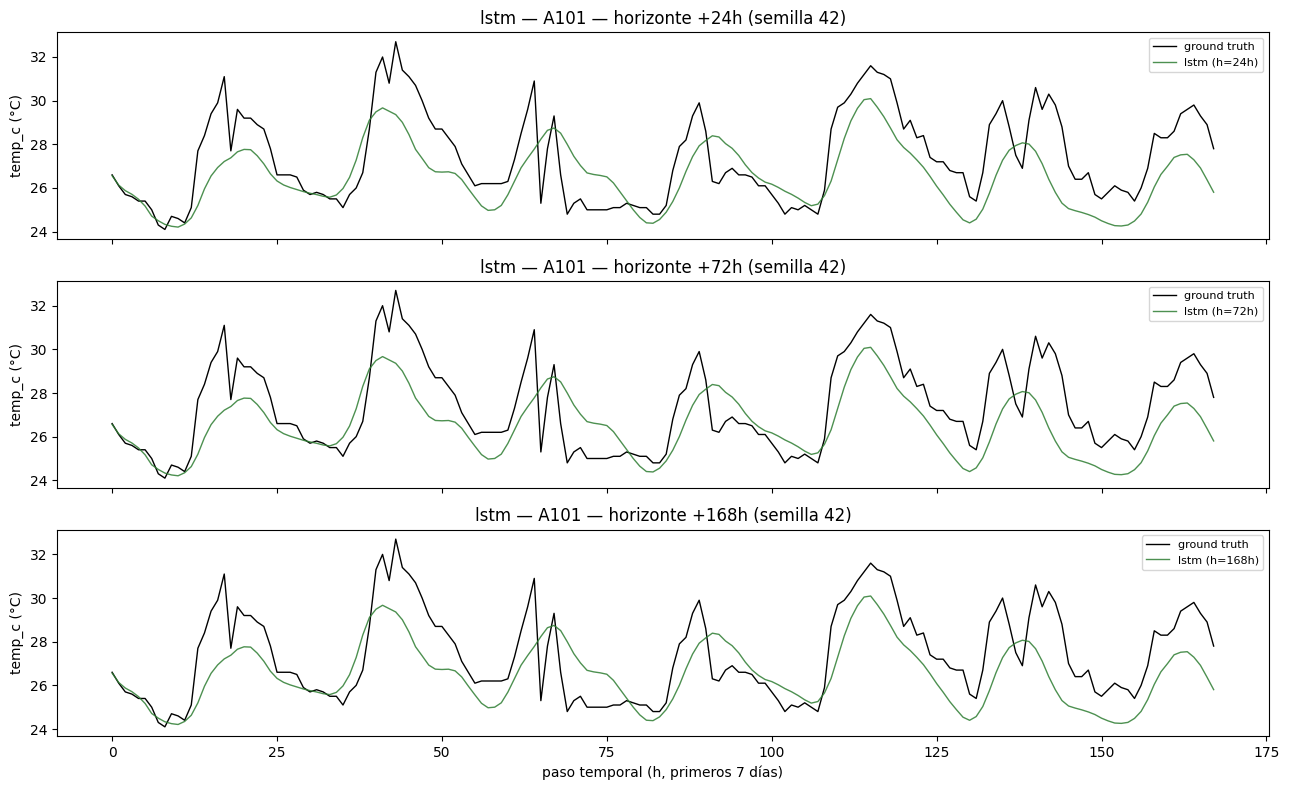

[lstm/A309 seed=42] sin predicciones.
  Corre: python -m src.training.runner --model lstm --seeds 5


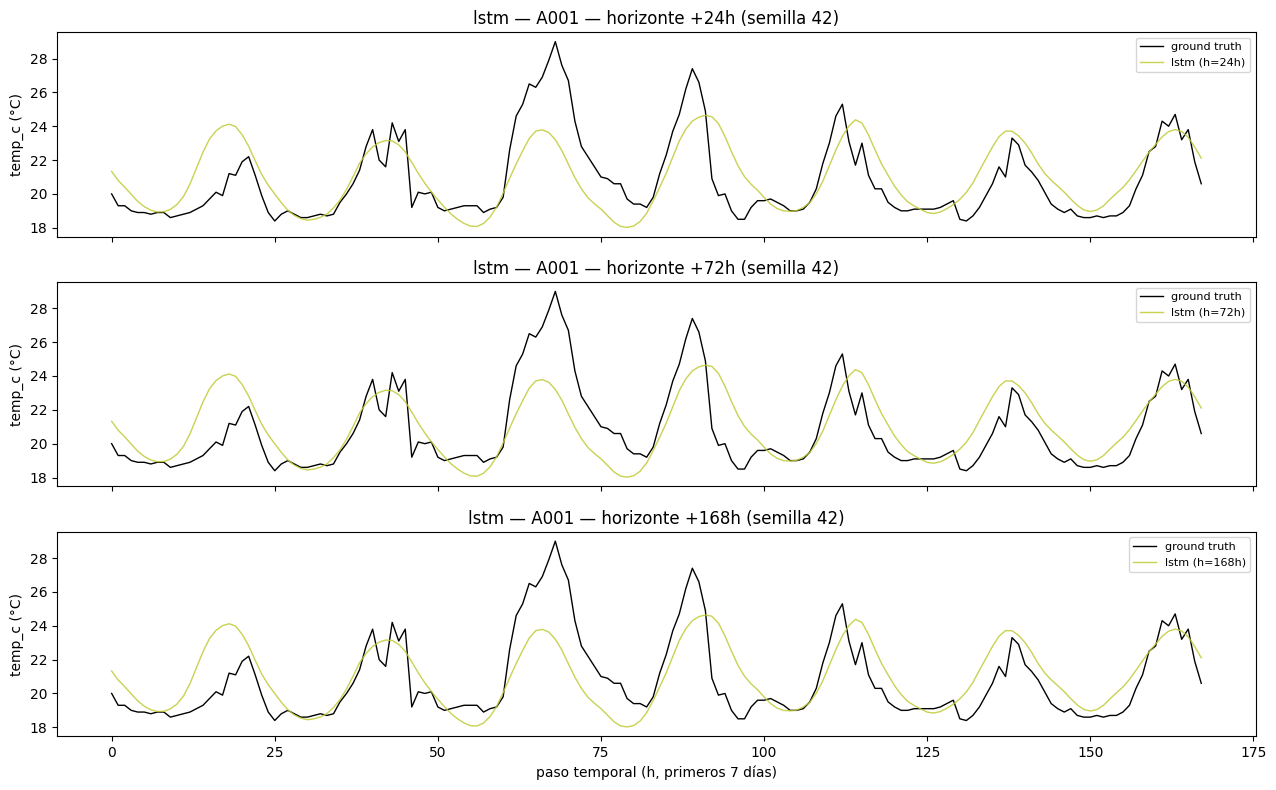

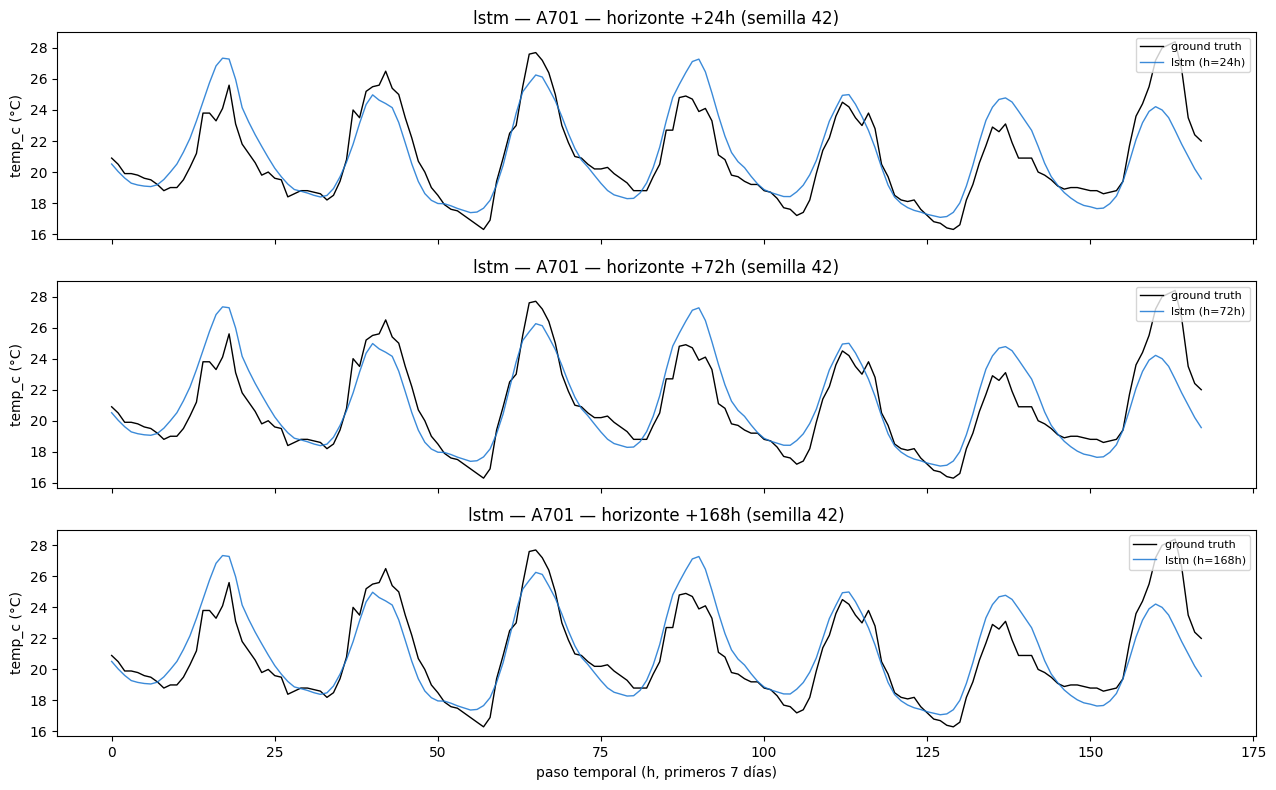

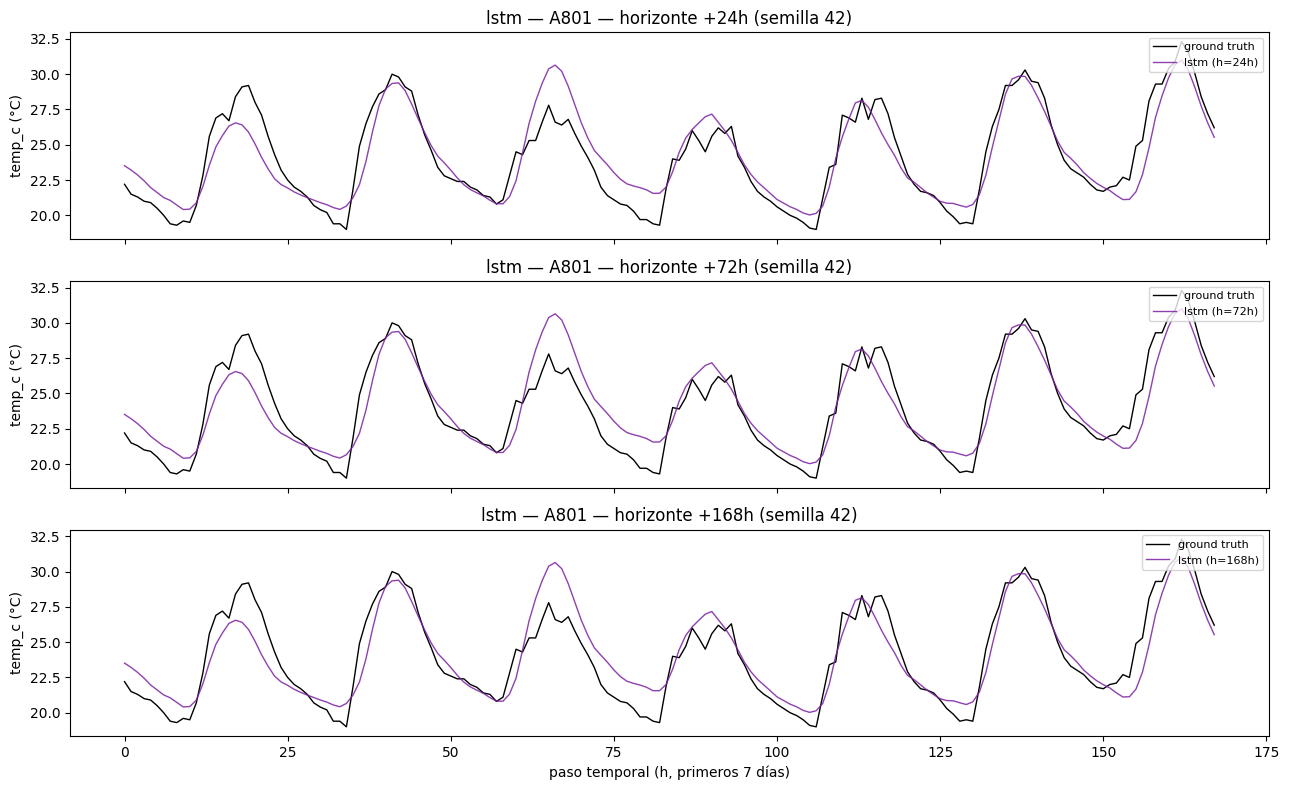

In [15]:
def plot_prediction_vs_truth(model: str, station: str, seed: int = 42,
                              window_days: int = 7, h_cuts: tuple = (24, 72, 168),
                              outname: str | None = None) -> None:
    """Predicción vs ground truth para los 3 cortes de horizonte."""
    preds = load_run_predictions(model, station, seed)
    if preds is None:
        print(f"[{model}/{station} seed={seed}] sin predicciones.")
        print(f"  Corre: python -m src.training.runner --model {model} --seeds 5")
        return
    y_true = preds["y_true"]   # (N, horizon, n_targets)
    y_pred = preds["y_pred"]
    # Tomamos las primeras N ventanas que cubren `window_days * 24` horas.
    n_windows = min(window_days * 24, y_true.shape[0])
    # Si el target es univariado, tomamos canal 0.
    if y_true.ndim == 3 and y_true.shape[-1] == 1:
        y_true = y_true[..., 0]
        y_pred = y_pred[..., 0]
    fig, axes = plt.subplots(len(h_cuts), 1, figsize=(13, 8), sharex=True)
    color = region_color(_region_of(station))
    for ax, h in zip(axes, h_cuts):
        h_idx = min(h, y_true.shape[1]) - 1
        yt = y_true[:n_windows, h_idx]
        yp = y_pred[:n_windows, h_idx]
        ax.plot(yt, color="black", lw=1.0, label="ground truth")
        ax.plot(yp, color=color, lw=1.0, alpha=0.85, label=f"{model} (h={h}h)")
        ax.set_title(f"{model} — {station} — horizonte +{h}h (semilla {seed})")
        ax.set_ylabel("temp_c (°C)")
        ax.legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("paso temporal (h, primeros 7 días)")
    plt.tight_layout()
    if outname:
        fig.savefig(FIG_DIR / outname, dpi=120, bbox_inches="tight")
    plt.show()


def _region_of(station: str) -> str:
    from src.utils.regions import region_of as _ro
    try:
        return _ro(station)
    except KeyError:
        return "Norte"  # fallback


# Por defecto: LSTM, semilla 42, 5 estaciones representativas (una por región).
for region, station in REPS.items():
    plot_prediction_vs_truth("lstm", station, seed=42,
                             outname=f"05_4_pred_vs_truth_lstm_{station}.png")

### 5.5 Tabla preliminar de métricas

In [16]:
def benchmark_table(models: list[str] = DEFAULT_MODELS,
                    seeds: list[int] = DEFAULT_SEEDS) -> pd.DataFrame:
    """Agrega resultados de los modelos disponibles en una tabla unificada.

    Cada fila = (modelo, métrica). Cada columna = estadístico (mean / std).
    Si un modelo no tiene runs todavía, queda omitido.
    """
    rows = []
    for m in models:
        df_m = aggregate_runs(m, seeds=seeds)
        if df_m.empty:
            continue
        # Promedio sobre estaciones del mean por métrica (panel-level).
        mean_cols = [c for c in df_m.columns if c.endswith("_mean")]
        std_cols  = [c for c in df_m.columns if c.endswith("_std")]
        panel_mean = df_m[mean_cols].mean()
        panel_std  = df_m[std_cols].mean()  # promedio del std intra-modelo
        n_estaciones = len(df_m)
        for col in mean_cols:
            base = col[:-len("_mean")]
            rows.append({
                "modelo": m,
                "metric": base,
                "panel_mean": float(panel_mean[col]),
                "panel_std_intra_seed": float(panel_std.get(f"{base}_std", float("nan"))),
                "n_estaciones": n_estaciones,
            })
    if not rows:
        print("Aún no hay resultados agregables. Corre los entrenamientos primero.")
        return pd.DataFrame()
    return (pd.DataFrame(rows)
              .set_index(["modelo", "metric"])
              .sort_index())


tabla = benchmark_table()
tabla

panel_mean  panel_std_intra_seed  n_estaciones
modelo      metric                                                      
gru         horizon        24.000000              0.000000             1
            mae_total       1.231989              0.004592             1
            mape_total      4.514228              0.025814             1
            n_samples    8569.000000              0.000000             1
            r2_total        0.629517              0.009418             1
            rmse_total      1.683179              0.021396             1
            smape_total     4.448101              0.018425             1
lstm        horizon        24.000000              0.000000             4
            mae_total       1.441838              0.016313             4
            mape_total      7.005316              0.135962             4
            n_samples    8569.000000              0.000000             4
            r2_total        0.772822              0.007445             4
            rmse_total      1.949551              0.026238             4
            smape_total     6.856670              0.064059             4
nbeats      horizon        24.000000              0.000000             1
            mae_total       2.072951              0.005048             1
            mape_total      7.499520              0.009838             1
            n_samples    8569.000000              0.000000             1
            r2_total        0.114953              0.004265             1
            rmse_total      2.601635              0.006268             1
            smape_total     7.457572              0.026483             1
persistence horizon        24.000000              0.000000             4
            mae_total       4.068818              0.000000             4
            mape_total     20.796325              0.000000             4
            n_samples    8569.000000              0.000000             4
            r2_total       -1.180242              0.000000             4
            rmse_total      6.366782              0.000000             4
            smape_total    18.323894              0.000000             4


## **6. Ejecución de Entrenamientos**



In [17]:
import subprocess
import sys
import os
import json
from pathlib import Path
from IPython.display import display, Markdown

# Asegurar que estamos en la raíz del proyecto, no en notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
assert (PROJECT_ROOT / "src" / "training" / "runner.py").exists(), \
    f"No encuentro runner.py — ¿estás en la raíz del proyecto?"


def train_model(model_name: str) -> int:
    """Lanza el entrenamiento del modelo y stream-ea logs al notebook.

    Returns el returncode (0 = OK, !=0 = error).
    """
    cmd = [sys.executable, "-m", "src.training.runner", "--model", model_name]
    print(f"\n{'='*60}")
    print(f"🚀 Entrenando: {model_name}")
    print(f"Comando: {' '.join(cmd)}")
    print(f"{'='*60}\n", flush=True)

    proc = subprocess.Popen(
        cmd,
        cwd=str(PROJECT_ROOT),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()

    print(f"\n{'='*60}")
    if proc.returncode == 0:
        print(f"✅ {model_name} completado.")
    else:
        print(f"❌ {model_name} falló con código {proc.returncode}.")
    print(f"{'='*60}")

    # Listar artefactos generados
    exp_dir = PROJECT_ROOT / "experiments" / model_name
    if exp_dir.exists():
        runs = list(exp_dir.glob("*/*/metrics.json"))
        print(f"\nArtefactos generados ({len(runs)} runs):")
        for r in sorted(runs)[:20]:
            print(f"  - {r.relative_to(PROJECT_ROOT)}")

    return proc.returncode


print("Función train_model lista. Usa train_model('<nombre>') en las siguientes celdas.")


PROJECT_ROOT = C:\Users\juana\proyecto-final-deep
Función train_model lista. Usa train_model('<nombre>') en las siguientes celdas.


In [18]:
# Persistence: baseline naive sin parámetros entrenables.
# Tiempo estimado con sampling: ~2-3 min.
train_model("persistence")



🚀 Entrenando: persistence
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model persistence

[2026-04-29 14:52:49] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-29 14:52:54] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 14:53:39] INFO    src.training.trainer :: epoch 01/05 â€” train=2.2082 val=2.2733 (4.2s) *
[2026-04-29 14:53:40] INFO    src.training.trainer :: epoch 02/05 â€” train=2.2074 val=2.2733 (1.2s)
[2026-04-29 14:53:40] INFO    src.training.trainer :: Early stopping en epoch 2 (best val=2.2733)
[2026-04-29 14:53:44] INFO    __main__ :: Run persistence/A101 seed=42 â€” RMSE total=4.5789
[2026-04-29 14:53:46] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 14:54:04

0

In [19]:
# LSTM: baseline recurrente. Familia RNN clásica.
# Tiempo estimado con sampling: ~5-10 min.
train_model("lstm")



🚀 Entrenando: lstm
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model lstm

[2026-04-29 14:56:29] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-29 14:56:34] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 14:57:48] INFO    src.training.trainer :: epoch 01/05 â€” train=0.3066 val=0.3347 (58.8s) *
[2026-04-29 14:58:46] INFO    src.training.trainer :: epoch 02/05 â€” train=0.1659 val=0.4062 (57.8s)
[2026-04-29 14:59:45] INFO    src.training.trainer :: epoch 03/05 â€” train=0.1062 val=0.4077 (59.4s)
[2026-04-29 15:00:42] INFO    src.training.trainer :: epoch 04/05 â€” train=0.0840 val=0.4038 (56.5s)
[2026-04-29 15:01:40] INFO    src.training.trainer :: epoch 05/05 â€” train=0.0730 val=0.4216 (57.8s)
[2026-04-29 15:01:48] INFO    __main__ :: Run lstm/A101 seed=42 â€” RMSE tot

0

In [20]:
# GRU: alternativa más liviana al LSTM.
# Tiempo estimado con sampling: ~5-8 min.
train_model("gru")



🚀 Entrenando: gru
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model gru

[2026-04-29 15:39:30] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-29 15:39:35] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 15:42:04] INFO    src.training.trainer :: epoch 01/05 â€” train=0.2992 val=0.3159 (118.1s) *
[2026-04-29 15:43:54] INFO    src.training.trainer :: epoch 02/05 â€” train=0.2022 val=0.3250 (109.7s)
[2026-04-29 15:45:43] INFO    src.training.trainer :: epoch 03/05 â€” train=0.1323 val=0.3581 (109.3s)
[2026-04-29 15:47:31] INFO    src.training.trainer :: epoch 04/05 â€” train=0.0983 val=0.3783 (108.2s)
[2026-04-29 15:49:19] INFO    src.training.trainer :: epoch 05/05 â€” train=0.0822 val=0.4092 (107.9s)
[2026-04-29 15:49:33] INFO    __main__ :: Run gru/A101 seed=42 â€” RMSE t

0

In [21]:
# TCN: convolucional dilatada para series temporales.
# Tiempo estimado con sampling: ~5-12 min.
train_model("tcn")



🚀 Entrenando: tcn
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model tcn

[2026-04-29 17:01:19] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-29 17:01:24] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 17:02:58] INFO    src.training.trainer :: epoch 01/05 â€” train=0.3258 val=0.3092 (64.6s) *
[2026-04-29 17:04:00] INFO    src.training.trainer :: epoch 02/05 â€” train=0.2514 val=0.3035 (61.6s) *
[2026-04-29 17:05:03] INFO    src.training.trainer :: epoch 03/05 â€” train=0.2233 val=0.3063 (63.1s)
[2026-04-29 17:06:04] INFO    src.training.trainer :: epoch 04/05 â€” train=0.1908 val=0.3112 (61.1s)
[2026-04-29 17:07:04] INFO    src.training.trainer :: epoch 05/05 â€” train=0.1578 val=0.3261 (59.9s)
[2026-04-29 17:07:13] INFO    __main__ :: Run tcn/A101 seed=42 â€” RMSE tota

0

In [22]:
# N-BEATS: arquitectura basada en bloques de basis para forecasting.
# Tiempo estimado con sampling: ~7-15 min.
train_model("nbeats")



🚀 Entrenando: nbeats
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model nbeats

[2026-04-29 17:46:49] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-29 17:46:54] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 17:47:37] INFO    src.training.trainer :: epoch 01/05 â€” train=0.7385 val=0.9355 (14.1s) *
[2026-04-29 17:47:50] INFO    src.training.trainer :: epoch 02/05 â€” train=0.5021 val=1.0086 (13.1s)
[2026-04-29 17:48:03] INFO    src.training.trainer :: epoch 03/05 â€” train=0.2783 val=1.0275 (12.9s)
[2026-04-29 17:48:16] INFO    src.training.trainer :: epoch 04/05 â€” train=0.1497 val=1.0403 (12.4s)
[2026-04-29 17:48:28] INFO    src.training.trainer :: epoch 05/05 â€” train=0.1034 val=1.0390 (12.4s)
[2026-04-29 17:48:33] INFO    __main__ :: Run nbeats/A101 seed=42 â€” RM

0

In [23]:
# Transformer: atención multi-head sobre toda la secuencia.
# Tiempo estimado con sampling: ~10-15 min.
train_model("transformer")



🚀 Entrenando: transformer
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model transformer

[2026-04-29 17:59:26] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-29 17:59:31] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
[2026-04-29 18:10:42] INFO    src.training.trainer :: epoch 01/05 â€” train=0.6972 val=0.4432 (655.1s) *
[2026-04-29 18:21:17] INFO    src.training.trainer :: epoch 02/05 â€” train=0.3112 val=0.3566 (634.8s) *
[2026-04-29 18:31:56] INFO    src.training.trainer :: epoch 03/05 â€” train=0.2600 val=0.3525 (639.3s) *
[2026-04-29 18:42:57] INFO    src.training.trainer :: epoch 04/05 â€” train=0.2341 val=0.3739 (661.0s)
[2026-04-29 18:53:58] INFO    src.training.trainer :: epoch 05/05 â€” train=0.2111 val=0.4032 (660.5s)
[2026-04-29 18:54:45] INFO    __main__ :: Run transfo

0

In [24]:
# TFT: Temporal Fusion Transformer - el paper guía.
# Tiempo estimado con sampling: ~12-20 min.
train_model("tft")



🚀 Entrenando: tft
Comando: c:\Users\juana\anaconda3\envs\proyecto-deep\python.exe -m src.training.runner --model tft

[2026-04-30 01:32:58] WARNING __main__ :: Sampling activo: epochs=5, seeds=2, stations=5 (['A101', 'A301', 'A001', 'A701', 'A801'])
[2026-04-30 01:33:03] WARNING src.data.split :: MUESTREO PROVISIONAL ACTIVO: 5 estaciones (['A101', 'A301', 'A001', 'A701', 'A801']), train_years=[2022, 2023]
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\juana\proyecto-final-deep\src\training\runner.py", line 229, in <module>
    main()
  File "C:\Users\juana\proyecto-final-deep\src\training\runner.py", line 225, in main
    run(args.config, args.model, args.seeds)
  File "C:\Users\juana\proyecto-final-deep\src\training\runner.py", line 216, in run
    run_one(model_cfg, cfg, seed=seed, station=station)
  File "C:\Users\juana\proyecto-final-deep\src\training\runner.py", line 135,

1

In [25]:
# Resumen del estado del benchmark
exp_dir = PROJECT_ROOT / "experiments"
modelos = ["persistence", "lstm", "gru", "tcn", "nbeats", "transformer", "tft"]
total = 0
print(f"{'Modelo':<15} {'Runs':>6}")
print("-" * 22)
for m in modelos:
    path = exp_dir / m
    n = len(list(path.glob("*/*/metrics.json"))) if path.exists() else 0
    total += n
    flag = "✅" if n >= 8 else ("⚠️" if n > 0 else "⏳")
    print(f"{flag} {m:<13} {n:>6}")
print("-" * 22)
print(f"{'TOTAL':<15} {total:>6}")
print(f"\nEsperado con sampling: 7 modelos × 4 estaciones × 2 seeds = 56 runs.")


Modelo            Runs
----------------------
✅ persistence        8
✅ lstm               8
✅ gru                8
✅ tcn                8
✅ nbeats             8
✅ transformer        8
⏳ tft                0
----------------------
TOTAL               48

Esperado con sampling: 7 modelos × 4 estaciones × 2 seeds = 56 runs.
